# City Explorer — Tel Aviv Flickr Analysis

End-to-end notebook for the whole project: **Part 1 (supervised)** and **Part 2 (unsupervised + agent simulation)**.

---

## 1. Data Cleaning

The entire cleaning pipeline runs in a single pass below. Steps applied, in order:

1. **Drop nulls** — remove any row with a missing value
2. **Date validity** — keep `2004 ≤ year < 2026` (Flickr launched 2004), valid month/day, and a parseable calendar date (drops e.g. Feb 30)
3. **Bounding box** — keep only coordinates inside the Tel Aviv area
4. **Land check** — drop points that fall in the sea (Natural Earth land polygons)
5. **Duplicate photos** — same user + same photo URL
6. **GPS jitter** — same user, same spot, same timestamp (collapses burst uploads)
7. **URL validation** — keep only well-formed Flickr photo URLs

Output: `flickr_clean.csv`

In [1]:
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

/home/roneng/city-explorer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ====================================================================
# DATA CLEANING — single pass: load -> validate -> spatial filter
#                 -> dedup -> save
# ====================================================================
RAW_FILE = "flickr_output_TelAviv100.xlsx - flickr_output_100.csv"
OUT_FILE = "flickr_clean.csv"

# Tel Aviv bounding box (lon/lat) and a valid Flickr photo-URL pattern
LON_MIN, LON_MAX = 34.70, 34.95
LAT_MIN, LAT_MAX = 31.95, 32.20
FLICKR_URL_RE = re.compile(r"^https?://www\.flickr\.com/photos/[^/]+/\d+/?$")

# --- Load -----------------------------------------------------------
df = pd.read_csv(RAW_FILE, skipinitialspace=True)
raw_count = len(df)

# --- 1. Drop rows with any null value -------------------------------
df = df.dropna()

# --- 2. Date validity -----------------------------------------------
# Flickr launched in 2004; current year is 2026. Keep 2004 inclusive.
df = df[(df["year"] >= 2004) & (df["year"] < 2026)]
df = df[(df["month"] >= 1) & (df["month"] <= 12)]
df = df[(df["day"] >= 1) & (df["day"] <= 31)]
# Build a real datetime; impossible dates (e.g. Feb 30) become NaT and drop.
df["date"] = pd.to_datetime(df[["year", "month", "day"]], errors="coerce")
df = df.dropna(subset=["date"])

# --- 3. Bounding box: keep points inside the Tel Aviv area ----------
df = df[df["lon"].between(LON_MIN, LON_MAX) & df["lat"].between(LAT_MIN, LAT_MAX)]

# --- 4. Land check: drop points in the sea --------------------------
# Spatial join against Natural Earth land polygons (WGS-84).
land = gpd.read_file(geodatasets.get_path("naturalearth.land")).to_crs(epsg=4326)
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326"
)
gdf = gpd.sjoin(gdf, land[["geometry"]], how="inner", predicate="within").drop(
    columns="index_right"
)

# --- 5. Remove duplicate photos (same user + same photo URL) --------
gdf = gdf.drop_duplicates(subset=["uid", "flickr_url"])

# --- 6. Remove GPS jitter (same user, spot, and timestamp) ----------
gdf = gdf.drop_duplicates(subset=["uid", "lon", "lat", "created_at"])

# --- 7. Validate Flickr URL format ----------------------------------
gdf = gdf[gdf["flickr_url"].astype(str).str.match(FLICKR_URL_RE)]

# --- Save (drop helper geometry/date columns) -----------------------
clean = gdf.drop(columns=["geometry", "date"])
clean.to_csv(OUT_FILE, index=False)

# --- Summary --------------------------------------------------------
removed = raw_count - len(clean)
print(f"Raw rows:     {raw_count:,}")
print(f"Clean rows:   {len(clean):,}  ({removed:,} removed, {removed / raw_count * 100:.1f}%)")
print(f"Unique users: {clean['uid'].nunique():,}")
print(f"Date range:   {gdf['date'].min().date()} -> {gdf['date'].max().date()}")
print(f"Saved -> {OUT_FILE}")
clean.head()

Raw rows:     63,831
Clean rows:   53,120  (10,711 removed, 16.8%)
Unique users: 2,152
Date range:   2004-01-01 -> 2016-04-27
Saved -> flickr_clean.csv


,lon,lat,flickr_url,day,month,year,created_at,uid,idx
0,34.742310,32.033473,https://www.flickr.com/photos/adrianalobba/102...,12,10,2013,10/12/13 11:37,65324157@N00,1
5,34.744022,32.033858,https://www.flickr.com/photos/134883768@N05/20...,16,4,2015,4/16/15 19:03,134883768@N05,6
6,34.744734,32.033348,https://www.flickr.com/photos/62957207@N03/168...,6,4,2015,4/6/15 10:52,62957207@N03,7
7,34.744452,32.032897,https://www.flickr.com/photos/philram/13763676...,10,4,2014,4/10/14 18:44,112113643@N05,8
8,34.744606,32.033837,https://www.flickr.com/photos/iph4n70m/5865381...,7,5,2011,5/7/11 13:27,41305869@N02,9


## 2. Exploratory Data Analysis

A quick look at the cleaned data before modelling: when photos were taken, where they
cluster, how many photos each user contributes, and how long each user stays active.
The activity-span distribution previews the tourist/local split formalised in the next
section (cutoff: 1 year).

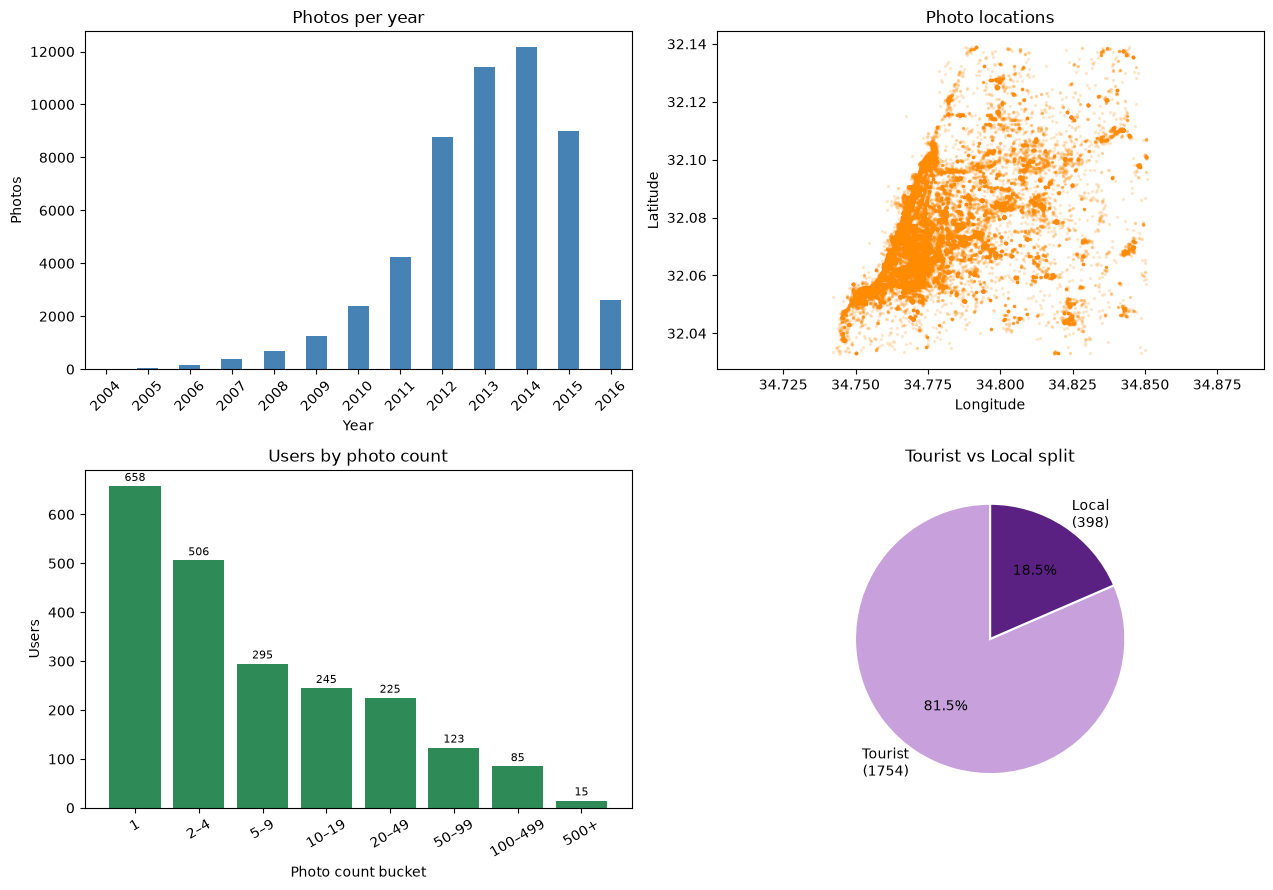

Users:               2,152
Span-based split:    1,754 tourist / 398 local  (82% tourist)
Median photos/user:  4
Users with 1 photo:  31%
Users with >=5:      988
Peak year:           2014


In [3]:
# Reload the cleaned data so this section is self-contained
eda = pd.read_csv(OUT_FILE)
eda["date"] = pd.to_datetime(eda[["year", "month", "day"]])

user_stats = eda.groupby("uid").agg(
    n_photos=("flickr_url", "size"),
    span_days=("date", lambda s: (s.max() - s.min()).days),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) Photos per year
eda["year"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set(title="Photos per year", xlabel="Year", ylabel="Photos")
axes[0, 0].tick_params(axis="x", rotation=45)

# (b) Spatial distribution of photos
axes[0, 1].scatter(eda["lon"], eda["lat"], s=2, alpha=0.15, color="darkorange")
axes[0, 1].set(title="Photo locations", xlabel="Longitude", ylabel="Latitude")
axes[0, 1].set_aspect("equal", adjustable="datalim")

# (c) Users by photo count — how many users fall in each bucket
photo_bins   = [1, 2, 5, 10, 20, 50, 100, 500, 10_000]
photo_labels = ["1", "2–4", "5–9", "10–19", "20–49", "50–99", "100–499", "500+"]
photo_counts = [
    ((user_stats["n_photos"] >= lo) & (user_stats["n_photos"] < hi)).sum()
    for lo, hi in zip(photo_bins, photo_bins[1:])
]
axes[1, 0].bar(photo_labels, photo_counts, color="seagreen")
axes[1, 0].set(title="Users by photo count", xlabel="Photo count bucket", ylabel="Users")
axes[1, 0].tick_params(axis="x", rotation=30)
for bar, val in zip(axes[1, 0].patches, photo_counts):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                    str(val), ha="center", va="bottom", fontsize=8)

# (d) Tourist / local split — pie chart
tourist_count = int((user_stats["span_days"] < 365).sum())
local_count   = int((user_stats["span_days"] >= 365).sum())
axes[1, 1].pie(
    [tourist_count, local_count],
    labels=[f"Tourist\n({tourist_count})", f"Local\n({local_count})"],
    colors=["#c7a0dc", "#5b2182"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1, 1].set_title("Tourist vs Local split")

plt.tight_layout()
plt.show()

tourist = tourist_count
local   = local_count
print(f"Users:               {len(user_stats):,}")
print(f"Span-based split:    {tourist:,} tourist / {local:,} local  ({tourist/len(user_stats)*100:.0f}% tourist)")
print(f"Median photos/user:  {user_stats['n_photos'].median():.0f}")
print(f"Users with 1 photo:  {(user_stats['n_photos'] == 1).mean()*100:.0f}%")
print(f"Users with >=5:      {(user_stats['n_photos'] >= 5).sum():,}")
print(f"Peak year:           {eda['year'].mode().iloc[0]}")

**Observations**

- **Temporal:** uploads ramp up through the early 2010s and peak in **2014**, then taper (matches Flickr's decline and the 2016 data cutoff).
- **Spatial:** photos hug the coastline and city centre — a dense core with sparse edges, exactly the kind of structure Part 2's clustering will target.
- **Users by photo count is heavily right-skewed:** median of **4**, with **31% of users contributing a single photo** while a handful contribute thousands.
- **Tourist/local split: 82% tourist (1,754 users) vs 18% local (398 users).** This imbalance is inflated by single-photo users whose span is automatically 0 days. That is why we **(a) keep only users with ≥5 photos** (~988 users) for reliable behavioural features, and **(b) use `class_weight="balanced"`** when training.

## 3. Labeling

Each user receives a binary label derived from their **activity span** (days between first and last photo):

- **Tourist (0):** span < 365 days
- **Local (1):** span ≥ 365 days

Because labeling and feature engineering both require the same per-user aggregation, the label is computed together with the features in the next section. `flickr_clean.csv` stays as pure photo-level data.

## 4. Feature Engineering

Per-user feature matrix computed in one aggregation pass. Features are grouped into four families:

| Family | Features |
|---|---|
| **Volume** | `n_photos`, `n_active_days`, `photos_per_active_day` |
| **Spatial** | `std_lon`, `std_lat`, `bbox_area`, `bbox_diag`, `radius_of_gyration`, `n_distinct_cells` |
| **Revisit** | `mean_photos_per_cell`, `location_entropy` |
| **Temporal rhythm** | `weekend_ratio`, `hour_std`, `n_distinct_months` |

**No-leakage rule:** `span_days` (= max_date − min_date) IS the label definition — it is computed here only to derive the label and is then dropped. No date-range or span-derived column enters the feature matrix.

In [4]:
FEATURE_FILE = "features.csv"
MIN_PHOTOS   = 5
SPAN_CUTOFF  = 365

df = pd.read_csv(OUT_FILE)
df["date"]       = pd.to_datetime(df[["year", "month", "day"]])
df["hour"]       = pd.to_datetime(df["created_at"], format="%m/%d/%y %H:%M", errors="coerce").dt.hour
df["is_weekend"] = df["date"].dt.dayofweek >= 5
df["cell"]       = df["lon"].round(2).astype(str) + "_" + df["lat"].round(2).astype(str)

# --- Label: span computed here, then dropped from features ----------
span = df.groupby("uid")["date"].agg(
    span_days=lambda s: (s.max() - s.min()).days
).reset_index()
span["label"] = (span["span_days"] >= SPAN_CUTOFF).astype(int)

# --- Volume ---------------------------------------------------------
vol = df.groupby("uid").agg(
    n_photos      =("flickr_url", "size"),
    n_active_days =("date", "nunique"),
).reset_index()
vol["photos_per_active_day"] = vol["n_photos"] / vol["n_active_days"].clip(lower=1)

# --- Spatial --------------------------------------------------------
spa = df.groupby("uid").agg(
    std_lon        =("lon", "std"),
    std_lat        =("lat", "std"),
    _min_lon       =("lon", "min"),
    _max_lon       =("lon", "max"),
    _min_lat       =("lat", "min"),
    _max_lat       =("lat", "max"),
    n_distinct_cells=("cell", "nunique"),
).reset_index()
spa["bbox_area"] = (spa["_max_lon"] - spa["_min_lon"]) * (spa["_max_lat"] - spa["_min_lat"])
spa["bbox_diag"] = np.sqrt(
    (spa["_max_lon"] - spa["_min_lon"])**2 + (spa["_max_lat"] - spa["_min_lat"])**2
)
spa.drop(columns=["_min_lon","_max_lon","_min_lat","_max_lat"], inplace=True)

# Radius of gyration — sqrt(mean squared distance from centroid)
centroid      = df.groupby("uid")[["lon","lat"]].transform("mean")
df["_sq_dist"]= (df["lon"] - centroid["lon"])**2 + (df["lat"] - centroid["lat"])**2
rog = df.groupby("uid")["_sq_dist"].mean().apply(np.sqrt).reset_index()
rog.columns   = ["uid", "radius_of_gyration"]
df.drop(columns=["_sq_dist"], inplace=True)

# --- Revisit --------------------------------------------------------
rev = df.groupby("uid").agg(
    mean_photos_per_cell=("cell", lambda s: len(s) / s.nunique()),
).reset_index()

def _entropy(s):
    p = s.value_counts(normalize=True)
    return -(p * np.log(p + 1e-12)).sum()

ent = df.groupby("uid")["cell"].apply(_entropy).reset_index()
ent.columns = ["uid", "location_entropy"]

# --- Temporal rhythm ------------------------------------------------
tmp = df.groupby("uid").agg(
    weekend_ratio     =("is_weekend", "mean"),
    hour_std          =("hour", "std"),
    n_distinct_months =("month", "nunique"),
).reset_index()

# --- Merge and filter -----------------------------------------------
feat = (
    span[["uid", "label"]]
    .merge(vol, on="uid")
    .merge(spa, on="uid")
    .merge(rog, on="uid")
    .merge(rev, on="uid")
    .merge(ent, on="uid")
    .merge(tmp, on="uid")
)
feat = feat[feat["n_photos"] >= MIN_PHOTOS].reset_index(drop=True)
feat.fillna(0, inplace=True)   # std/entropy NaN for users with all-same values → 0
feat.to_csv(FEATURE_FILE, index=False)

feat_cols = [c for c in feat.columns if c not in ["uid", "label"]]
tourists  = (feat["label"] == 0).sum()
locals_   = (feat["label"] == 1).sum()
print(f"Users after ≥{MIN_PHOTOS}-photo filter: {len(feat)}")
print(f"  Tourist (0): {tourists}  ({tourists/len(feat)*100:.1f}%)")
print(f"  Local   (1): {locals_}  ({locals_/len(feat)*100:.1f}%)")
print(f"Features ({len(feat_cols)}): {feat_cols}")
print(f"Saved -> {FEATURE_FILE}")
feat.head()

Users after ≥5-photo filter: 988
  Tourist (0): 635  (64.3%)
  Local   (1): 353  (35.7%)
Features (14): ['n_photos', 'n_active_days', 'photos_per_active_day', 'std_lon', 'std_lat', 'n_distinct_cells', 'bbox_area', 'bbox_diag', 'radius_of_gyration', 'mean_photos_per_cell', 'location_entropy', 'weekend_ratio', 'hour_std', 'n_distinct_months']
Saved -> features.csv


,uid,label,n_photos,n_active_days,photos_per_active_day,std_lon,std_lat,n_distinct_cells,bbox_area,bbox_diag,radius_of_gyration,mean_photos_per_cell,location_entropy,weekend_ratio,hour_std,n_distinct_months
0,100024582@N05,0,62,1,62.000000,0.000000,0.000000,1,0.000000e+00,0.000000,0.000000,62.000000,-1.000089e-12,0.000000,0.940313,1
1,100473971@N02,0,5,2,2.500000,0.000190,0.000074,1,8.300000e-08,0.000527,0.000183,5.000000,-1.000089e-12,0.000000,12.049896,1
2,100597270@N04,1,58,47,1.234043,0.023880,0.018109,34,8.282841e-03,0.128864,0.029710,1.705882,3.350755e+00,0.241379,2.022334,11
3,100617112@N07,0,13,2,6.500000,0.004435,0.010016,4,6.237490e-04,0.040407,0.010525,3.250000,7.937301e-01,0.923077,2.025479,1
4,100778874@N04,1,5,3,1.666667,0.011654,0.018951,4,1.132224e-03,0.053520,0.019899,1.250000,1.332179e+00,0.000000,1.483240,3


## 5. Model Training

A **Random Forest** classifier trained on the 14 behavioral/spatial features.

- **Split:** 80/20 stratified train/test (preserves the 64/36 tourist/local ratio in both sets)
- **`class_weight="balanced"`** — down-weights the majority class automatically, so the model optimises for both classes rather than just predicting tourist everywhere
- **`random_state=42`** — reproducible results

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

feat = pd.read_csv(FEATURE_FILE)

FEATURE_COLS = [c for c in feat.columns if c not in ["uid", "label"]]
X = feat[FEATURE_COLS].values
y = feat["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

print(f"Training set: {X_train.shape[0]} users  "
      f"(tourist: {(y_train==0).sum()}, local: {(y_train==1).sum()})")
print(f"Test set:     {X_test.shape[0]} users  "
      f"(tourist: {(y_test==0).sum()}, local: {(y_test==1).sum()})")
print("Model trained.")

Training set: 790 users  (tourist: 508, local: 282)
Test set:     198 users  (tourist: 127, local: 71)
Model trained.
